# Customer Churn Analysis — Telecom
**Tools used:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn  
**Dataset:** Telco Customer Churn (Kaggle)

---
I wanted to explore a classic business problem — why do customers leave? This is called **churn**, and reducing it is a top priority for most subscription-based companies. Telecom is a great industry to look at because competition is high and switching providers is easy.

My goal here was simple: find out *who* is likely to churn and *why*, then build a basic model to predict it.

## Step 1 — Install and import libraries

In [15]:
# Install everything needed for this project
# You only need to run this once
!pip3 install pandas numpy matplotlib seaborn scikit-learn kagglehub -q

zsh:1: command not found: pip


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

all good!


## Step 2 — Load the dataset

I'm using the Telco Customer Churn dataset from Kaggle. It has ~7,000 rows, one per customer, with info like their contract type, monthly bill, tenure, and whether they churned (yes/no).

`kagglehub` downloads it straight into the notebook — no manual CSV download needed.

In [17]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")

Loaded 7043 rows and 21 columns


## Step 3 — Get a feel for the data

Before doing anything fancy, I like to just look at what we're working with.

In [18]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [20]:
# Check for missing values
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

## Step 4 — Clean up a few things

Two issues I spotted:

1. `TotalCharges` is stored as text (object) instead of a number — some rows have a blank space instead of a value. I'll convert it and fill the blanks with the median.
2. The `Churn` column says "Yes" or "No" — I need to convert that to 1 and 0 so the model can use it.

In [21]:
# Fix TotalCharges — convert to number, blank strings become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill the 11 missing TotalCharges rows with the median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

n = len(df)
churn_rate = df['Churn'].mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")
print(f"That's {df['Churn'].sum()} customers out of {n}")

Overall churn rate: 26.5%
That's 1869 customers out of 7043


## Step 5 — Explore the data

This is the fun part. I looked at churn rates across different groups to find patterns.

### Contract type

In [22]:
churn_by_contract = df.groupby('Contract')['Churn'].mean() * 100
print(churn_by_contract.round(1).to_string())

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8


### Internet service

In [23]:
churn_by_internet = df.groupby('InternetService')['Churn'].mean() * 100
print(churn_by_internet.round(1).to_string())

InternetService
DSL            19.0
Fiber optic    41.9
No              7.4


### Tech support & online security

In [24]:
churn_by_support  = df.groupby('TechSupport')['Churn'].mean() * 100
churn_by_security = df.groupby('OnlineSecurity')['Churn'].mean() * 100
print('Tech Support:')
print(churn_by_support.round(1).to_string())
print()
print('Online Security:')
print(churn_by_security.round(1).to_string())

Tech Support:
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2

Online Security:
OnlineSecurity
No                     41.8
No internet service     7.4
Yes                    14.6


### Tenure — how long has the customer been around?

In [25]:
df['TenureBand'] = pd.cut(df['tenure'],
                           bins=[0, 12, 24, 48, 72],
                           labels=['0-12 mo', '12-24 mo', '24-48 mo', '48-72 mo'])
churn_by_tenure = df.groupby('TenureBand', observed=False)['Churn'].mean() * 100
print(churn_by_tenure.round(1).to_string())

TenureBand
0-12 mo     47.7
12-24 mo    28.7
24-48 mo    20.4
48-72 mo     9.5


### Monthly charges — do churners pay more?

In [26]:
avg_churned = df[df['Churn'] == 1]['MonthlyCharges'].mean()
avg_stayed  = df[df['Churn'] == 0]['MonthlyCharges'].mean()
print('Avg monthly bill — churned: $' + str(round(avg_churned, 2)))
print('Avg monthly bill — stayed:  $' + str(round(avg_stayed, 2)))

Avg monthly bill — churned: $74.44
Avg monthly bill — stayed:  $61.27


## Step 6 — Visualise the patterns

Numbers are one thing, but charts make it much easier to see what's going on.

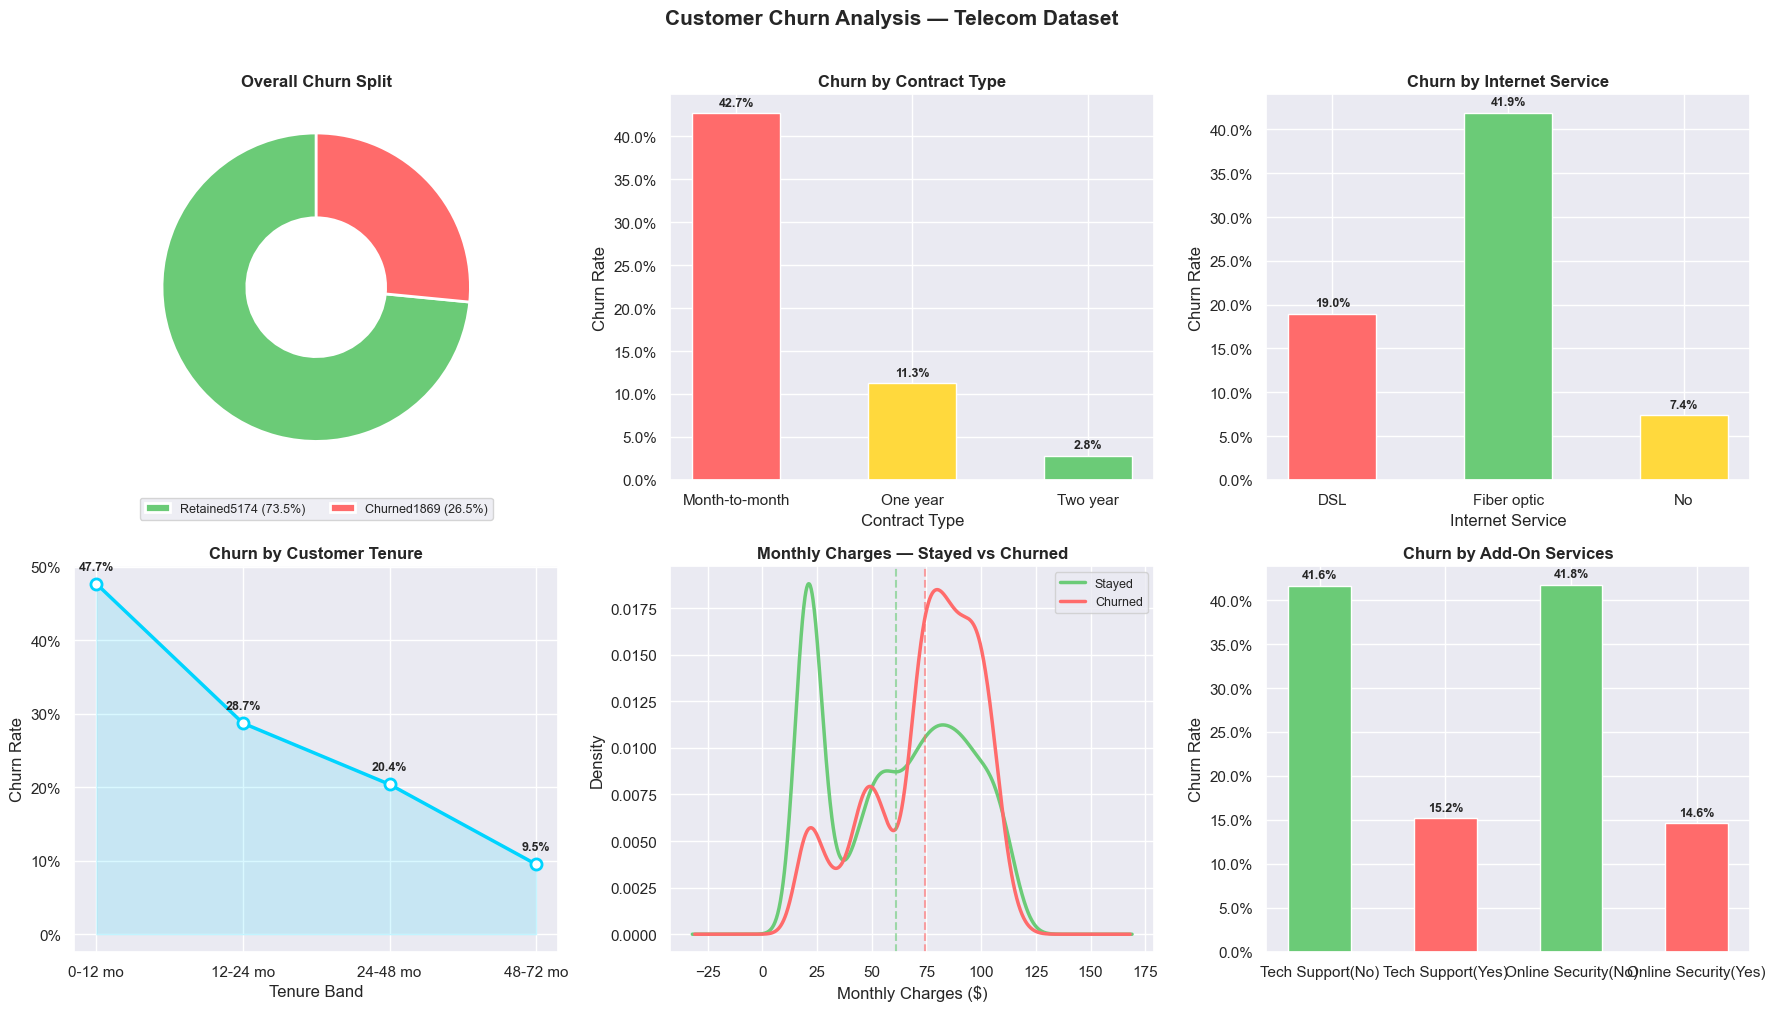

In [29]:
sns.set_theme(style='darkgrid', palette='muted')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Churn Analysis — Telecom Dataset', fontsize=15, fontweight='bold', y=1.01)

# 1. Donut chart — overall churn split
ax = axes[0, 0]
sizes  = [df['Churn'].value_counts()[0], df['Churn'].value_counts()[1]]
labels = [f'Retained{sizes[0]} ({sizes[0]/n*100:.1f}%)',
          f'Churned{sizes[1]} ({sizes[1]/n*100:.1f}%)']
wedges, _ = ax.pie(sizes, colors=['#6bcb77', '#ff6b6b'], startangle=90,
                   wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
ax.set_title('Overall Churn Split', fontweight='bold')
ax.legend(wedges, labels, loc='lower center', fontsize=9, ncol=2, bbox_to_anchor=(0.5, -0.12))

# 2. Contract type
ax = axes[0, 1]
bars = ax.bar(churn_by_contract.index, churn_by_contract.values,
              color=['#ff6b6b', '#ffd93d', '#6bcb77'], edgecolor='white', width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Churn by Contract Type', fontweight='bold')
ax.set_xlabel('Contract Type'); ax.set_ylabel('Churn Rate')
for bar, val in zip(bars, churn_by_contract.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Internet service
ax = axes[0, 2]
bars = ax.bar(churn_by_internet.index, churn_by_internet.values,
              color=['#ff6b6b', '#6bcb77', '#ffd93d'], edgecolor='white', width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Churn by Internet Service', fontweight='bold')
ax.set_xlabel('Internet Service'); ax.set_ylabel('Churn Rate')
for bar, val in zip(bars, churn_by_internet.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Tenure
ax = axes[1, 0]
ax.plot(churn_by_tenure.index, churn_by_tenure.values,
        marker='o', color='#00d4ff', linewidth=2.5, markersize=8,
        markerfacecolor='white', markeredgecolor='#00d4ff', markeredgewidth=2)
ax.fill_between(range(len(churn_by_tenure)), churn_by_tenure.values, alpha=0.15, color='#00d4ff')
ax.set_xticks(range(len(churn_by_tenure)))
ax.set_xticklabels(churn_by_tenure.index)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Churn by Customer Tenure', fontweight='bold')
ax.set_xlabel('Tenure Band'); ax.set_ylabel('Churn Rate')
for i, val in enumerate(churn_by_tenure.values):
    ax.annotate(f'{val:.1f}%', (i, val), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

# 5. Monthly charges distribution
ax = axes[1, 1]
df[df['Churn'] == 0]['MonthlyCharges'].plot(kind='kde', ax=ax,
    color='#6bcb77', linewidth=2.5, label='Stayed')
df[df['Churn'] == 1]['MonthlyCharges'].plot(kind='kde', ax=ax,
    color='#ff6b6b', linewidth=2.5, label='Churned')
ax.axvline(avg_churned, color='#ff6b6b', linestyle='--', alpha=0.6, linewidth=1.5)
ax.axvline(avg_stayed,  color='#6bcb77', linestyle='--', alpha=0.6, linewidth=1.5)
ax.set_title('Monthly Charges — Stayed vs Churned', fontweight='bold')
ax.set_xlabel('Monthly Charges ($)'); ax.set_ylabel('Density')
ax.legend(fontsize=9)

# 6. Add-on services
ax = axes[1, 2]
support_clean  = churn_by_support[churn_by_support.index.isin(['Yes', 'No'])]
security_clean = churn_by_security[churn_by_security.index.isin(['Yes', 'No'])]
support_r  = support_clean.rename(index={'Yes': 'Tech Support(Yes)', 'No': 'Tech Support(No)'})
security_r = security_clean.rename(index={'Yes': 'Online Security(Yes)', 'No': 'Online Security(No)'})
combined = pd.concat([support_r, security_r])
bars = ax.bar(combined.index, combined.values,
              color=['#6bcb77', '#ff6b6b', '#6bcb77', '#ff6b6b'], edgecolor='white', width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Churn by Add-On Services', fontweight='bold')
ax.set_ylabel('Churn Rate')
for bar, val in zip(bars, combined.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()

### What I noticed from the charts

- **Month-to-month contracts have by far the highest churn.** Customers on longer contracts rarely leave — probably because they're locked in, but also because they've committed.
- **Fiber optic customers churn more than DSL customers.** This was surprising at first, but it likely comes down to price — fiber is more expensive, so customers are quicker to shop around.
- **New customers (0–12 months) are the most at risk.** Churn drops significantly after the first year. The first few months are the most critical window.
- **Customers without tech support or online security churn more.** Add-on services seem to create stickiness — people feel more invested in the product.

## Step 7 — Prepare the data for the model

Machine learning models only understand numbers. So I need to:
1. Drop columns that don't help (like `customerID` — it's just a label)
2. Convert text columns like "Yes/No" into numbers using one-hot encoding
3. Split data into training and test sets
4. Scale the features so no single column dominates

In [30]:
# Drop columns we don't need
df_model = df.drop(columns=['TenureBand', 'customerID'])

# Convert all remaining text columns into numbers (one-hot encoding)
# drop_first=True avoids the dummy variable trap
object_cols = df_model.select_dtypes(include='object').columns.tolist()
df_model = pd.get_dummies(df_model, columns=object_cols, drop_first=True)

# Drop any remaining rows with NaN — just to be safe before feeding into the model
df_model = df_model.dropna()

# Separate features (X) from the target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# 80% for training, 20% for testing
# stratify=y makes sure both splits have the same churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — brings everything onto the same scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training rows : {X_train.shape[0]}")
print(f"Test rows     : {X_test.shape[0]}")
print(f"Features      : {X_train.shape[1]}")

Training rows : 5625
Test rows     : 1407
Features      : 30


## Step 8 — Train the model

I'm using **Logistic Regression** — a simple but effective algorithm for yes/no predictions. It estimates the probability that a customer will churn based on their features.

`class_weight='balanced'` is important here because only ~26% of customers churned — if we ignore this, the model will be biased towards predicting "no churn" for everyone.

In [31]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_s, y_train)
print("Model trained!")

Model trained!


## Step 9 — Evaluate the model

I'll check how well the model performs on the test set — data it has never seen before.

In [32]:
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC Score : {auc:.4f}")
print(f"Accuracy      : {(y_pred == y_test).mean()*100:.1f}%")
print()
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

AUC-ROC Score : 0.8350
Accuracy      : 72.6%

              precision    recall  f1-score   support

      Stayed       0.91      0.70      0.79      1033
     Churned       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



**AUC-ROC** measures how well the model separates churners from non-churners. A score of 0.5 = random guessing, 1.0 = perfect. Anything above 0.75 is solid for a simple model like this.

## Step 10 — What actually drives churn?

Logistic Regression gives each feature a coefficient — the bigger the number, the more that feature influences the prediction. I'll look at the top 10.

In [33]:
feat_imp = pd.Series(np.abs(model.coef_[0]), index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print("Top 10 features driving churn predictions:")
print()
print(feat_imp.head(10).round(4).to_string())

Top 10 features driving churn predictions:

tenure                            1.2639
MonthlyCharges                    0.9287
InternetService_Fiber optic       0.7461
Contract_Two year                 0.6386
TotalCharges                      0.6233
Contract_One year                 0.3267
StreamingTV_Yes                   0.2597
StreamingMovies_Yes               0.2529
MultipleLines_Yes                 0.2028
PaymentMethod_Electronic check    0.1937


## Step 11 — Model charts

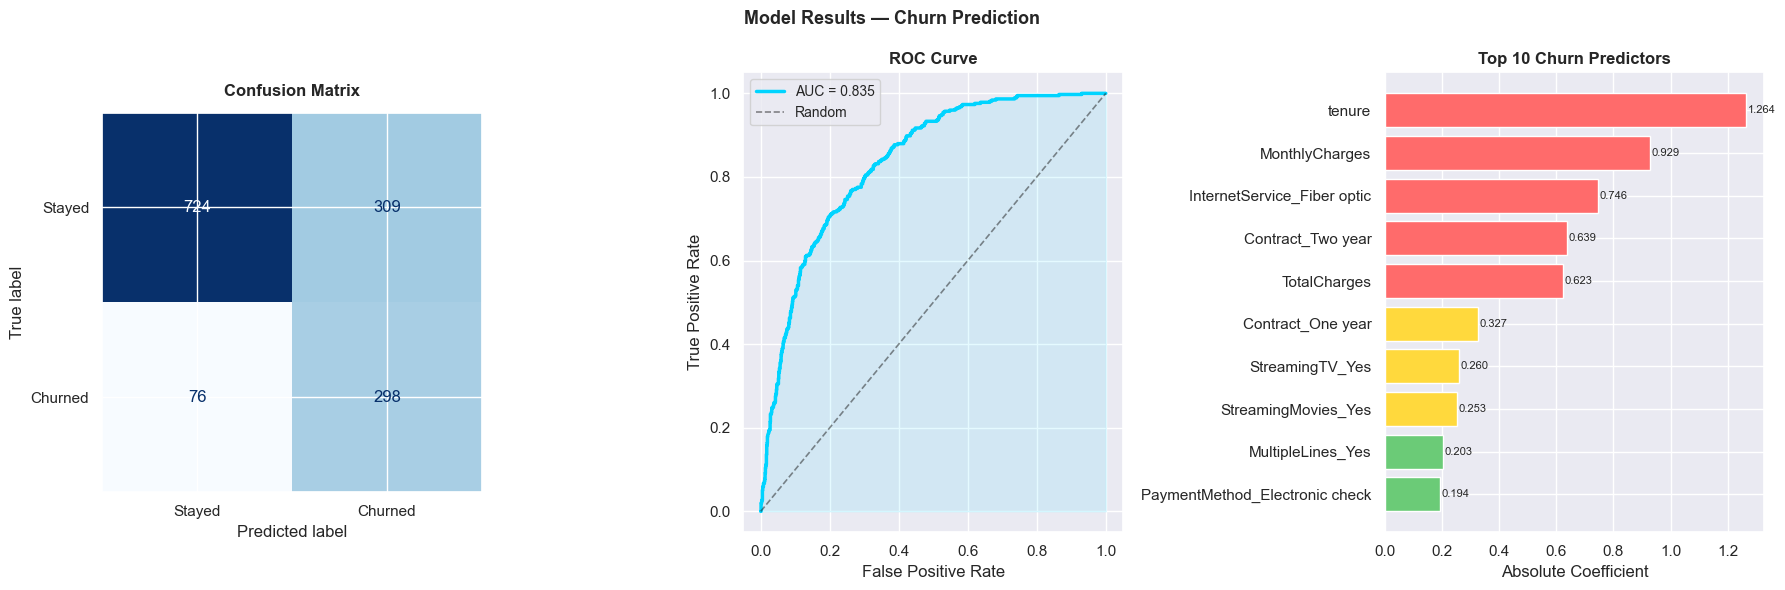

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Results — Churn Prediction', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)

# Confusion matrix
ax = axes[0]
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontweight='bold', pad=12)

# ROC curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, color='#00d4ff', linewidth=2.5, label=f'AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.5, label='Random')
ax.fill_between(fpr, tpr, alpha=0.1, color='#00d4ff')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(fontsize=10)

# Feature importance
ax = axes[2]
top10 = feat_imp.head(10).sort_values()
colors_fi = ['#ff6b6b' if v > 0.5 else '#ffd93d' if v > 0.25 else '#6bcb77'
             for v in top10.values]
bars = ax.barh(top10.index, top10.values, color=colors_fi, edgecolor='white')
ax.set_xlabel('Absolute Coefficient')
ax.set_title('Top 10 Churn Predictors', fontweight='bold')
for bar, val in zip(bars, top10.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('churn_model.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 — Key takeaways


In [38]:
churn_rate = df['Churn'].mean() * 100

print('Overall churn rate', churn_rate);
print('Fiber Optic Churn: ', churn_by_internet.get('Fiber optic',float('nan')))


Overall churn rate 26.536987079369588
Fiber Optic Churn:  41.89276485788114
